# Process Geo Districts

Fuzzy-matches district names between a districts CSV and a GeoDataFrame
shapefile, then saves the Geojson file with easily matchable labels.

Dependencies:
    mamba install geopandas rapidfuzz

In [3]:
import geopandas as gpd
from matplotlib import pyplot as plt
import pandas as pd
from rapidfuzz import process, fuzz
import re
import os

In [6]:
gdf_orig = gpd.read_file("../raw_data/03_DISTRICT/DISTRICT.shp")
gdf_orig.head(3)

,OBJECTID,STATE_CODE,DISTRICT,GaPa_NaPa,Type_GN,Province,Area,Shape_Leng,Shape_Area,geometry
0,1,7,DOTI,Adharsha,Gaunpalika,Sudur Pashchim,0.0,282908.088904,2.054599e+09,"POLYGON ((81.03282 29.1862, 81.03295 29.18651,..."
1,2,3,RAMECHHAP,Doramba,Gaunpalika,Bagmati,0.0,295289.035440,1.565522e+09,"POLYGON ((86.22432 27.38306, 86.22421 27.38301..."
2,3,5,DANG,Babai,Gaunpalika,5,0.0,352004.991843,3.059781e+09,"POLYGON ((82.7484 27.82304, 82.74881 27.82289,..."


<Axes: >

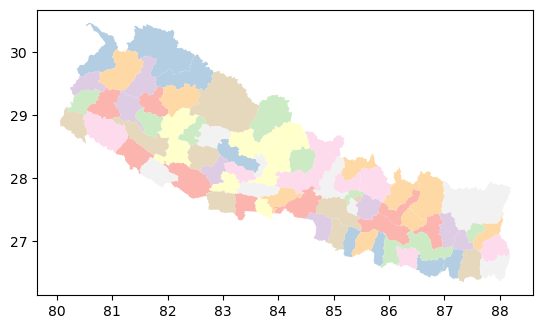

In [7]:
gdf_orig.plot(cmap="Pastel1")

In [11]:
gdf = gpd.read_file("../proc_data/geom_elev.geojson")

In [12]:
# ---------------------------------------------------------------------------
# Normalization
# ---------------------------------------------------------------------------

def normalize(name: str) -> str:
    """
    Lowercase, strip leading digits/codes, replace underscores and punctuation
    with spaces, collapse whitespace.

    Examples:
        "501 RUKUM EAST"  -> "rukum east"
        "RUKUM_E"         -> "rukum e"
        "DANG DEUKHURI"   -> "dang deukhuri"
    """
    s = str(name).lower()
    s = re.sub(r"^\d+\s*", "", s)       # strip leading numeric code
    s = re.sub(r"[_\-/\\]", " ", s)    # underscores/dashes -> space
    s = re.sub(r"[^\w\s]", "", s)       # remove remaining punctuation
    s = re.sub(r"\s+", " ", s).strip()
    return s


# ---------------------------------------------------------------------------
# Fuzzy matching
# ---------------------------------------------------------------------------

def build_match_table(
    geo_names: list[str],
    district_names: list[str],
    threshold: int,
) -> pd.DataFrame:
    """
    For each name in geo_names, find the best match in district_names using
    rapidfuzz token_set_ratio (handles abbreviations and word-order differences).

    Returns a DataFrame with columns:
        geo_name_original, geo_name_norm,
        matched_district_original, matched_district_norm,
        score, accepted
    """
    norm_districts = {normalize(d): d for d in district_names}
    norm_district_keys = list(norm_districts.keys())

    rows = []
    for geo_orig in geo_names:
        geo_norm = normalize(geo_orig)

        result = process.extractOne(
            geo_norm,
            norm_district_keys,
            scorer=fuzz.token_set_ratio,
        )

        if result is None:
            rows.append({
                "geo_name_original": geo_orig,
                "geo_name_norm": geo_norm,
                "matched_district_original": None,
                "matched_district_norm": None,
                "score": 0,
                "accepted": False,
            })
            continue

        matched_norm, score, _ = result
        matched_orig = norm_districts[matched_norm]
        accepted = score >= threshold

        rows.append({
            "geo_name_original": geo_orig,
            "geo_name_norm": geo_norm,
            "matched_district_original": matched_orig,
            "matched_district_norm": matched_norm,
            "score": score,
            "accepted": accepted,
        })

    return pd.DataFrame(rows)


def print_warnings(match_table: pd.DataFrame, threshold: int) -> None:
    """Print warnings for low-confidence or unmatched rows."""
    bad = match_table[~match_table["accepted"]]
    if bad.empty:
        return

    print(f"\n[warning] {len(bad)} geo district(s) could not be confidently matched "
          f"(score < {threshold}) and will have no health data in the merged output:")
    for _, row in bad.iterrows():
        score_str = f"score={row['score']}" if row["score"] > 0 else "no match found"
        best = f" -> best candidate: '{row['matched_district_original']}'" if row["matched_district_original"] else ""
        print(f"  '{row['geo_name_original']}' ({score_str}){best}")


def print_summary(match_table: pd.DataFrame) -> None:
    total = len(match_table)
    accepted = match_table["accepted"].sum()
    print(f"\nMatch summary: {accepted}/{total} geo districts matched successfully.")
    if accepted == total:
        print("  All districts matched. ✓")

In [13]:
districts_df = pd.read_csv("../proc_data/districts.csv", dtype={"organisationunitcode": str})
districts_df.head(3)

,organisationunitid,organisationunitname,province_name,province_code,organisationunitcode,month,p_cases,np_cases
0,DLyaDAF00hm,204 MAHOTTARI,2 Madhesh Province,2,204,2024-11-27,2.0,1.0
1,vjL1uSC10Jh,701 BAJURA,7 Sudurpashchim Province,7,701,2024-11-27,0.0,0.0
2,CNFRaFUfLjo,111 JHAPA,1 Koshi Province,1,111,2024-11-27,0.0,14.0


In [14]:
# ---- Fuzzy match --------------------------------------------------------
geo_names = gdf["DISTRICT"].tolist()
district_names = districts_df["organisationunitname"].tolist()

match_table = build_match_table(geo_names, district_names, 85)

print_warnings(match_table, 85)
print_summary(match_table)


[warning] 2 geo district(s) could not be confidently matched (score < 85) and will have no health data in the merged output:
  'RUKUM_W' (score=83.33333333333333) -> best candidate: '501 RUKUM EAST'
  'RUKUM_E' (score=83.33333333333333) -> best candidate: '501 RUKUM EAST'

Match summary: 75/77 geo districts matched successfully.


In [17]:
# ---- Build geo->district name map for accepted matches ------------------
accepted = match_table[match_table["accepted"]]
geo_to_district = dict(zip(accepted["geo_name_original"], accepted["matched_district_original"]))
geo_to_district['RUKUM_W'] = '608 RUKUM WEST'
geo_to_district['RUKUM_E'] = '501 RUKUM EAST'

# ---- Merge --------------------------------------------------------------
# Add a join key to the GeoDataFrame using the matched district name
gdf["_match_key"] = gdf["DISTRICT"].map(geo_to_district)

In [18]:
gdf

,OBJECTID,STATE_CODE,DISTRICT,GaPa_NaPa,Type_GN,Province,Area,Shape_Leng,Shape_Area,elev_mean,elev_max,geometry,_match_key
0,1,7,DOTI,Adharsha,Gaunpalika,Sudur Pashchim,0.0,282908.088904,2.054599e+09,1502.189801,3286.547363,"POLYGON ((81.03282 29.1862, 81.03295 29.18651,...",706 DOTI
1,2,3,RAMECHHAP,Doramba,Gaunpalika,Bagmati,0.0,295289.035440,1.565522e+09,2079.053268,6804.967285,"POLYGON ((86.22432 27.38306, 86.22421 27.38301...",310 RAMECHHAP
2,3,5,DANG,Babai,Gaunpalika,5,0.0,352004.991843,3.059781e+09,621.401243,2058.496338,"POLYGON ((82.7484 27.82304, 82.74881 27.82289,...",510 DANG
3,4,5,RUPANDEHI,Butwal,Upamahanagarpalika,5,0.0,229898.404296,1.304475e+09,155.310414,1110.452637,"POLYGON ((83.40117 27.42033, 83.40096 27.4202,...",508 RUPANDEHI
4,5,3,SINDHULI,Dudhouli,Nagarpalika,Bagmati,0.0,352777.949556,2.486021e+09,750.830417,2381.372314,"POLYGON ((86.30632 27.10883, 86.30639 27.10839...",311 SINDHULI
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,73,3,DHADING,Benighat Rorang,Gaunpalika,Bagmati,0.0,359568.911316,1.906729e+09,1617.547515,7049.753418,"POLYGON ((85.22971 27.77288, 85.22997 27.77277...",304 DHADING
73,74,1,TAPLEJUNG,Aathrai Tribeni,Gaunpalika,1,0.0,301482.064043,3.643851e+09,3703.996869,8543.113281,"POLYGON ((88.06782 27.43923, 88.06763 27.43902...",101 TAPLEJUNG
74,75,5,BANKE,Baijanath,Gaunpalika,5,0.0,235805.166929,1.882279e+09,256.580251,1212.665039,"POLYGON ((81.96168 27.92315, 81.96156 27.9228,...",511 BANKE
75,76,5,PALPA,Bagnaskali,Gaunpalika,5,0.0,270596.477602,1.461895e+09,983.926905,1936.822998,"POLYGON ((83.757 27.90307, 83.75747 27.9032, 8...",506 PALPA


In [21]:
# ---- Save ---------------------------------------------------------------
proc_data_folder = "../proc_data"

print(f"\nSaving merged GeoJSON")
gdf.to_file(os.path.join(proc_data_folder, "geom_processed.geojson"), driver="GeoJSON")
print(f"Done. {len(gdf):,} features written.")


Saving merged GeoJSON
Done. 77 features written.
